# 4. Rispondere alle domande
Trasforma le seguenti richiesti in formule per estrarre infromazioni dal dataframe
- Mostrami le vendite maggiori di 10

- Mostrami i dati del 2018

- Mostrami le vendite maggiori di 13 e l'anno è il 2018

- Mostrami tutto TRANNE i casi in cui le vendite sono maggiori di 13 e l'anno è il 2018

- Mostrami i dati dove le vendite divise per 3 sono maggiori di 3

- Mostrami i dipendenti i cui nomi sono alfabeticamente dopo la J



In [21]:
import pandas as pd

sales = pd.DataFrame(
    data={
        "employee": [
            "Katrina",
            "Guanyu",
            "Jan",
            "Roman",
            "Jacqueline",
            "Paola",
            "Esperanza",
            "Alaina",
            "Egweyn",
        ],
        "sales": [14, 17, 6, 12, 8, 3, 7, 15, 5],
        "year": [2018, 2019, 2020, 2018, 2020, 2019, 2019, 2020, 2020],
    }
)

#1
sales[sales['sales']>10]

#2
sales.query('year == 2018')

#3
sales.query('sales > 13 and year == 2018')

#4
sales.query('sales < 13 and year != 2018')

#5
sales.query('sales/3 > 3')

#6
sales.query('employee > "J"')

,employee,sales,year
0,Katrina,14,2018
2,Jan,6,2020
3,Roman,12,2018
4,Jacqueline,8,2020
5,Paola,3,2019


# 5. Analisi di un dataset di video giochi
1. Quanti videogiochi sono stati pubblicati
2. Quali sono i generi più popolari? Mostralo con un bar plot
3. Plotta l'evoluzione del numero di giochi pubblicati nel tempo
4. Prova a riprodurre questo plot 

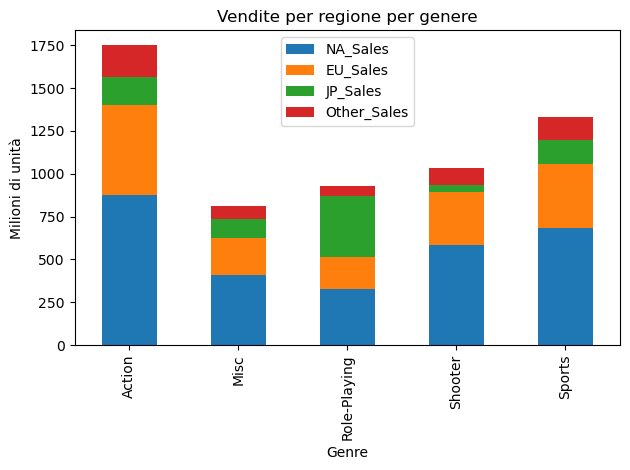


In [2]:
# Import dei pacchetti
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Caricamento del dataset
url = 'https://zenodo.org/record/5898311/files/vgsales.csv'
df = pd.read_csv(url)

df_no_duplicates = df.drop_duplicates(subset='Name')
#df[df.duplicated(subset='Name') == True]
df_no_duplicates['Name'].count()

np.int64(11493)

Text(0, 0.5, 'Sales')

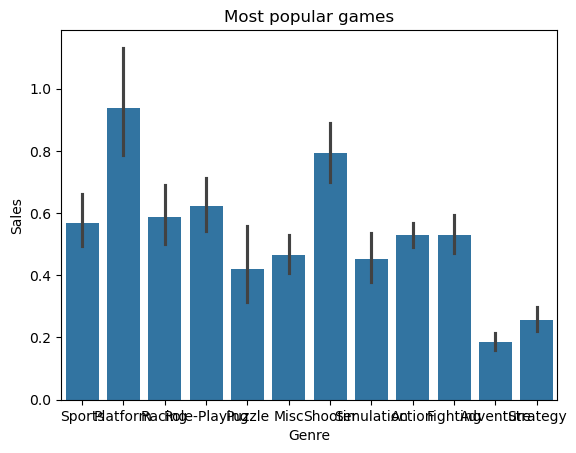

In [3]:
sns.barplot(data=df, x='Genre', y='Global_Sales')
plt.title('Most popular games')
plt.xlabel('Genre')
plt.ylabel('Sales')

<Axes: xlabel='Year', ylabel='Name'>

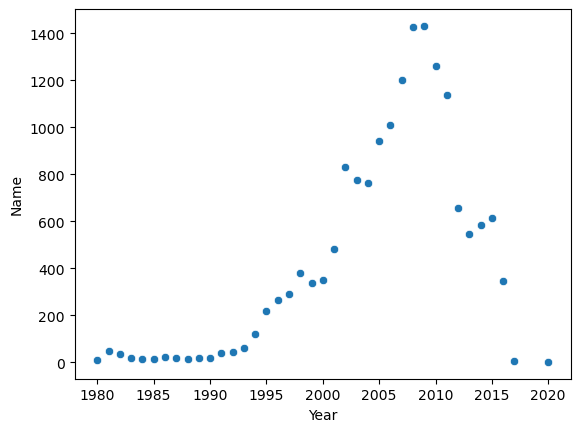

In [96]:
grouped_year = df.groupby('Year')['Name'].count()
year_df = grouped_year.to_frame('Name')
sns.scatterplot(data=year_df, x=year_df.index, y='Name')

              NA_Sales  EU_Sales  JP_Sales  Other_Sales
Genre                                                  
Action          877.83    525.00    159.95       187.38
Adventure       105.80     64.13     52.07        16.81
Fighting        223.59    101.32     87.35        36.68
Misc            410.24    215.98    107.76        75.32
Platform        447.05    201.63    130.77        51.59
Puzzle          123.78     50.78     57.31        12.55
Racing          359.42    238.39     56.69        77.27
Role-Playing    327.28    188.06    352.31        59.61
Shooter         582.60    313.27     38.28       102.69
Simulation      183.31    113.38     63.70        31.52
Sports          683.35    376.85    135.37       134.97
Strategy         68.70     45.34     49.46        11.36


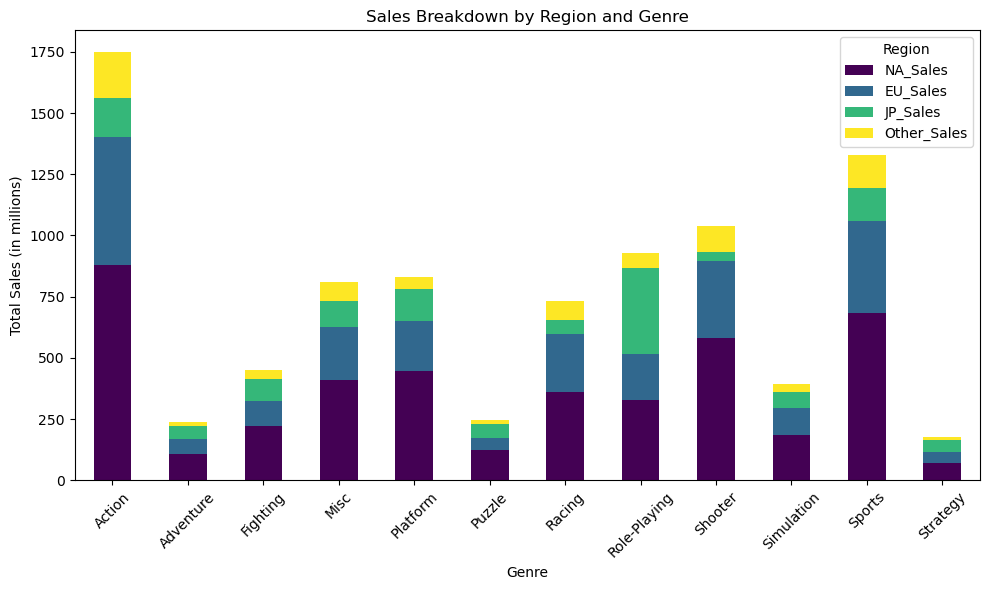

In [7]:
df_grouped = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
print(df_grouped)
# 2. Crea il grafico a barre in pila (stacked) direttamente dal DataFrame raggruppato
df_grouped.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10, 6))

# 3. Formattazione del grafico
plt.title('Sales Breakdown by Region and Genre')
plt.xlabel('Genre')
plt.ylabel('Total Sales (in millions)')
plt.xticks(rotation=45)
plt.legend(title='Region')
plt.tight_layout() # Ottimizza gli spazi per non tagliare le etichette
plt.show()